In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

In [2]:
!git clone https://github.com/PantheonPlusSH0ES/DataRelease.git

Cloning into 'DataRelease'...
remote: Enumerating objects: 3313, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3313 (delta 4), reused 4 (delta 4), pack-reused 3306 (from 3)
Receiving objects: 100% (3313/3313), 504.22 MiB | 20.61 MiB/s, done.
Resolving deltas: 100% (231/231), done.
Updating files: 100% (3095/3095), done.


In [3]:
df=pd.read_csv("/content/DataRelease/Pantheon+_Data/4_DISTANCES_AND_COVAR/Pantheon+SH0ES.dat",sep=r'\s+')

In [4]:
df

,CID,IDSURVEY,zHD,zHDERR,zCMB,zCMBERR,zHEL,zHELERR,m_b_corr,m_b_corr_err_DIAG,...,PKMJDERR,NDOF,FITCHI2,FITPROB,m_b_corr_err_RAW,m_b_corr_err_VPEC,biasCor_m_b,biasCorErr_m_b,biasCor_m_b_COVSCALE,biasCor_m_b_COVADD
0,2011fe,51,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.74571,1.516210,...,0.1071,36,26.88590,0.864470,0.0991,1.4960,0.0381,0.005,1.000,0.003
1,2011fe,56,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.80286,1.517230,...,0.0579,101,88.30640,0.812220,0.0971,1.4960,-0.0252,0.003,1.000,0.004
2,2012cg,51,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.47030,0.781906,...,0.0278,165,233.50000,0.000358,0.0399,0.7134,0.0545,0.019,1.000,0.036
3,2012cg,56,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.49190,0.798612,...,0.0667,55,100.12200,0.000193,0.0931,0.7134,0.0622,0.028,1.000,0.040
4,1994DRichmond,50,0.00299,0.00084,0.00299,0.00004,0.00187,0.00004,11.52270,0.880798,...,0.0522,146,109.83900,0.988740,0.0567,0.6110,0.0650,0.009,1.000,0.006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1696,rutledge,106,1.61505,0.00545,1.61499,0.00500,1.61399,0.00500,25.90650,0.331927,...,1.7256,8,2.92493,0.938980,0.2230,0.0106,-0.0203,0.005,1.000,0.002
1697,geta,106,1.69706,0.04006,1.69702,0.04000,1.70000,0.04000,26.03330,0.379521,...,1.8973,12,9.15387,0.689730,0.3209,0.0748,0.2680,0.005,0.633,0.000
1698,stone,106,1.80119,0.02014,1.80111,0.02000,1.80000,0.02000,26.23350,0.280685,...,1.1631,11,11.69320,0.387140,0.2370,0.0358,-0.0968,0.004,0.641,0.000
1699,wilson,106,1.91165,0.00263,1.91160,0.00100,1.91401,0.00100,26.17030,0.357624,...,1.4902,9,5.54378,0.784570,0.3168,0.0044,-0.3835,0.013,0.604,0.000


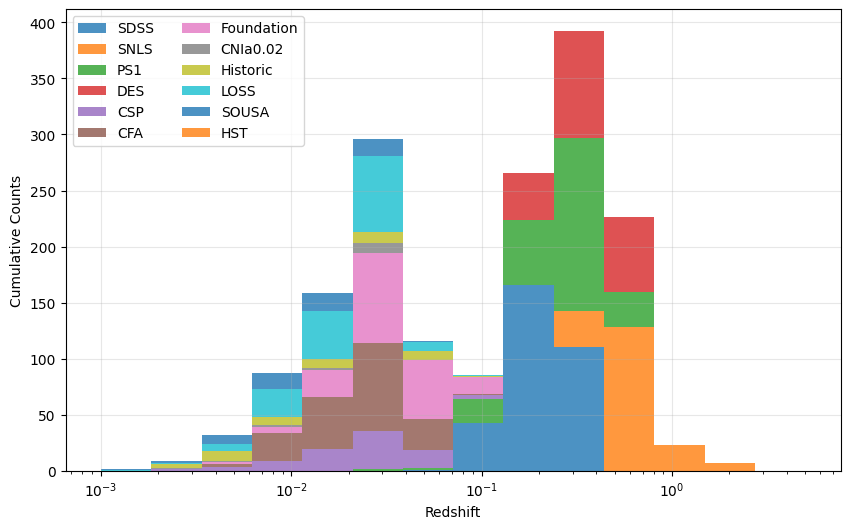

In [5]:
import numpy as np
import matplotlib.pyplot as plt

survey_groups = {
    1: "SDSS",
    4: "SNLS",
    5: "CSP",
    10: "DES",
    15: "PS1",

    18: "CNIa0.02",

    50: "Historic",

    51: "LOSS",
    57: "LOSS",

    56: "SOUSA",

    61: "CFA",
    62: "CFA",
    63: "CFA",
    64: "CFA",
    65: "CFA",
    66: "CFA",

    100: "HST",
    101: "HST",
    106: "HST",

    150: "Foundation"
}

df["SURVEY_NAME"] = df["IDSURVEY"].map(survey_groups)

# Ordem dos surveys
survey_order = [
    "SDSS",
    "SNLS",
    "PS1",
    "DES",
    "CSP",
    "CFA",
    "Foundation",
    "CNIa0.02",
    "Historic",
    "LOSS",
    "SOUSA",
    "HST"
]

z_data = []

for survey in survey_order:

    z = df[df["SURVEY_NAME"] == survey]["zHD"]

    z_data.append(z)

# bins logarítmicos
bins = np.logspace(-3, 0.7, 15)

plt.figure(figsize=(10,6))

plt.hist(
    z_data,
    bins=bins,
    stacked=True,
    label=survey_order,
    alpha=0.8
)

plt.xscale("log")

plt.xlabel("Redshift")
plt.ylabel("Cumulative Counts")

plt.legend(
    ncol=2,
    fontsize=10,
    frameon=True
)
plt.grid(alpha=0.3)

plt.show()

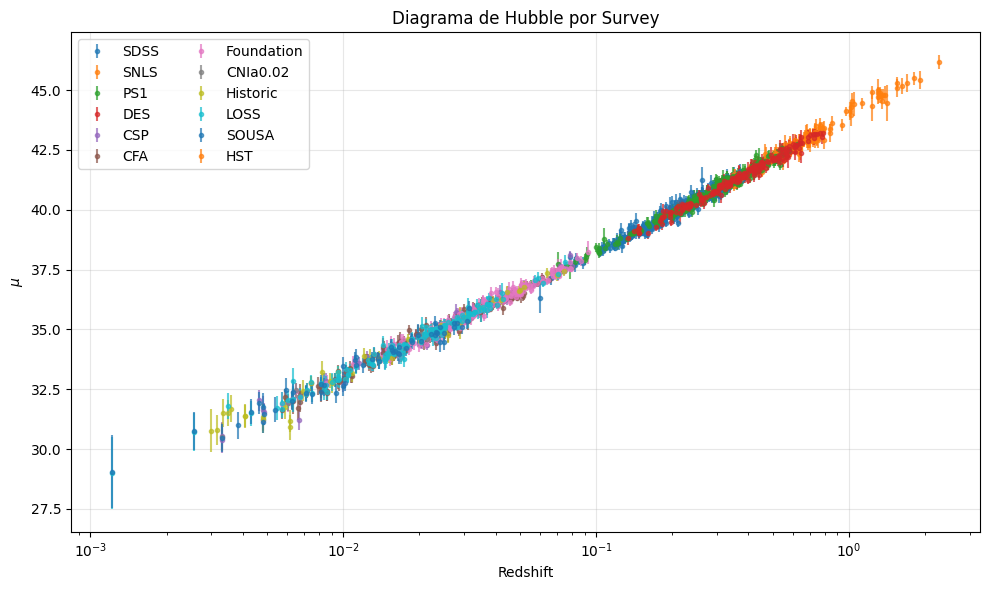

In [6]:
plt.figure(figsize=(10,6))

for survey in survey_order:

    df_survey = df[df["SURVEY_NAME"] == survey]

    plt.errorbar(
        df_survey["zHD"],
        df_survey["MU_SH0ES"],
        yerr=df_survey["MU_SH0ES_ERR_DIAG"],
        fmt=".",
        alpha=0.7,
        label=survey
    )

plt.xscale("log")

plt.xlabel("Redshift")
plt.ylabel(r"$\mu$")

plt.title("Diagrama de Hubble por Survey")

plt.legend(ncol=2)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# Modelo Cosmológico $\Lambda$CDM Plano

Para comparar os dados observacionais com previsões teóricas, utilizaremos o modelo cosmológico padrão $\Lambda$CDM plano. Nesse modelo, a expansão do Universo é descrita pela função:

$ E(z)=\sqrt{\Omega_m(1+z)^3+\Omega_\Lambda} $

onde:

- $\Omega_m$ representa a densidade de matéria;
- $\Omega_\Lambda$ representa a densidade associada à energia escura;
- $z$ é o redshift.

Assumindo um Universo plano:

$\Omega_\Lambda = 1-\Omega_m$


A distância luminosa é dada por:

$d_L(z)=\frac{c(1+z)}{H_0}\int_0^z \frac{dz'}{E(z')}$

onde:

- $c$ é a velocidade da luz;
- $H_0$ é a constante de Hubble.

Finalmente, o módulo de distância teórico é calculado por:
$\mu = 5\log_{10}(d_L)+25 $

com $d_L$ medido em megaparsecs (Mpc).

A seguir, utilizaremos essas equações para comparar as previsões do modelo $\Lambda$CDM com os dados observacionais do catálogo Pantheon+.

In [7]:
c = 299792.458  # km/s

H0 = 73
Om0 = 0.3
Ol0 = 1 - Om0
def E(z):
    return np.sqrt(Om0*(1+z)**3 + Ol0)

In [8]:
def luminosity_distance(z):

    integral, _ = quad(
        lambda zp: 1/E(zp),
        0,
        z
    )

    dL = (c*(1+z)/H0) * integral

    return dL

In [9]:
def mu_theory(z):

    dL = luminosity_distance(z)

    return 5*np.log10(dL) + 25

In [10]:
z_model = np.logspace(-3, 0.7, 300)

mu_model = []

for z in z_model:

    mu_model.append(mu_theory(z))

mu_model = np.array(mu_model)

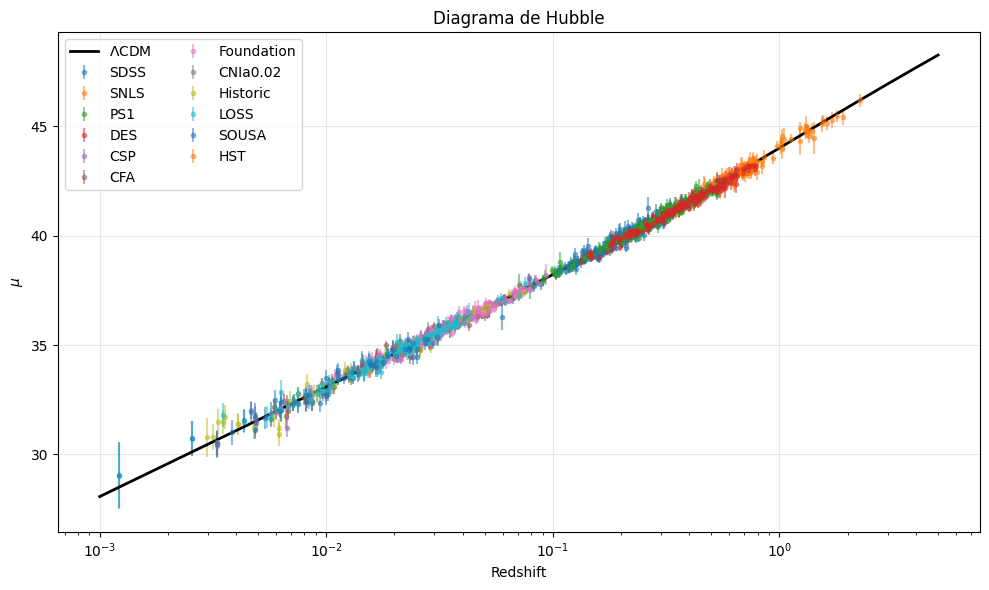

In [11]:
plt.figure(figsize=(10,6))

for survey in survey_order:

    df_survey = df[df["SURVEY_NAME"] == survey]

    plt.errorbar(
        df_survey["zHD"],
        df_survey["MU_SH0ES"],
        yerr=df_survey["MU_SH0ES_ERR_DIAG"],
        fmt=".",
        alpha=0.5,
        label=survey
    )

# Curva teórica
plt.plot(
    z_model,
    mu_model,
    color="black",
    lw=2,
    label=r"$\Lambda$CDM"
)

plt.xscale("log")

plt.xlabel("Redshift")
plt.ylabel(r"$\mu$")

plt.title("Diagrama de Hubble")

plt.legend(ncol=2)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [12]:
mu_lcdm = []

for z in df["zHD"]:

    mu_lcdm.append(mu_theory(z))

mu_lcdm = np.array(mu_lcdm)

In [13]:
df["MU_RESIDUAL"] = df["MU_SH0ES"] - mu_lcdm

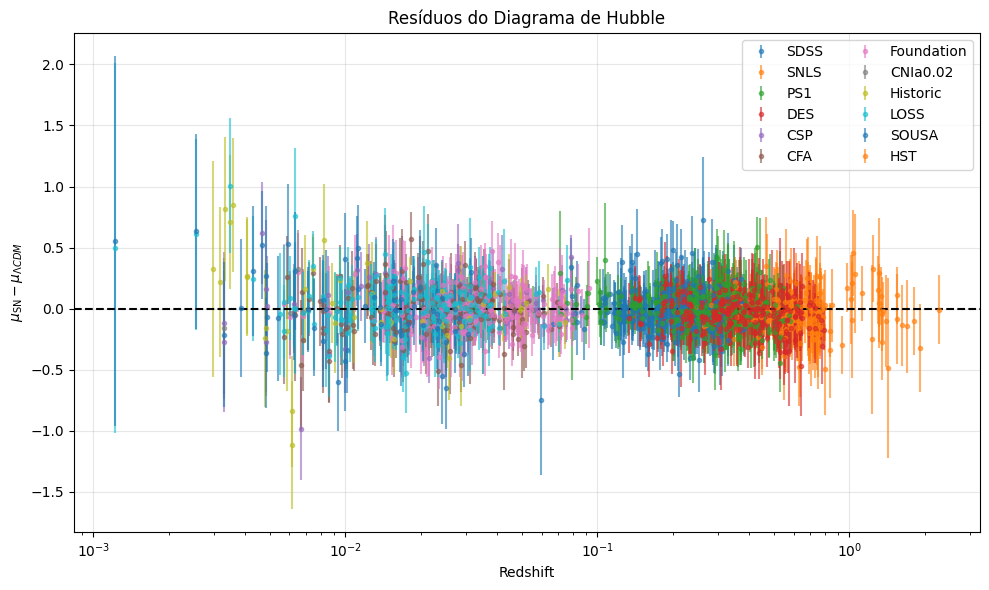

In [14]:
plt.figure(figsize=(10,6))

for survey in survey_order:

    df_survey = df[df["SURVEY_NAME"] == survey]

    plt.errorbar(
        df_survey["zHD"],
        df_survey["MU_RESIDUAL"],
        yerr=df_survey["MU_SH0ES_ERR_DIAG"],
        fmt=".",
        alpha=0.6,
        label=survey
    )

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.xscale("log")

plt.xlabel("Redshift")
plt.ylabel(r"$\mu_{\mathrm{SN}} - \mu_{\Lambda CDM}$")

plt.title("Resíduos do Diagrama de Hubble")

plt.legend(ncol=2)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [15]:
df["logz"] = np.log10(df["zHD"])

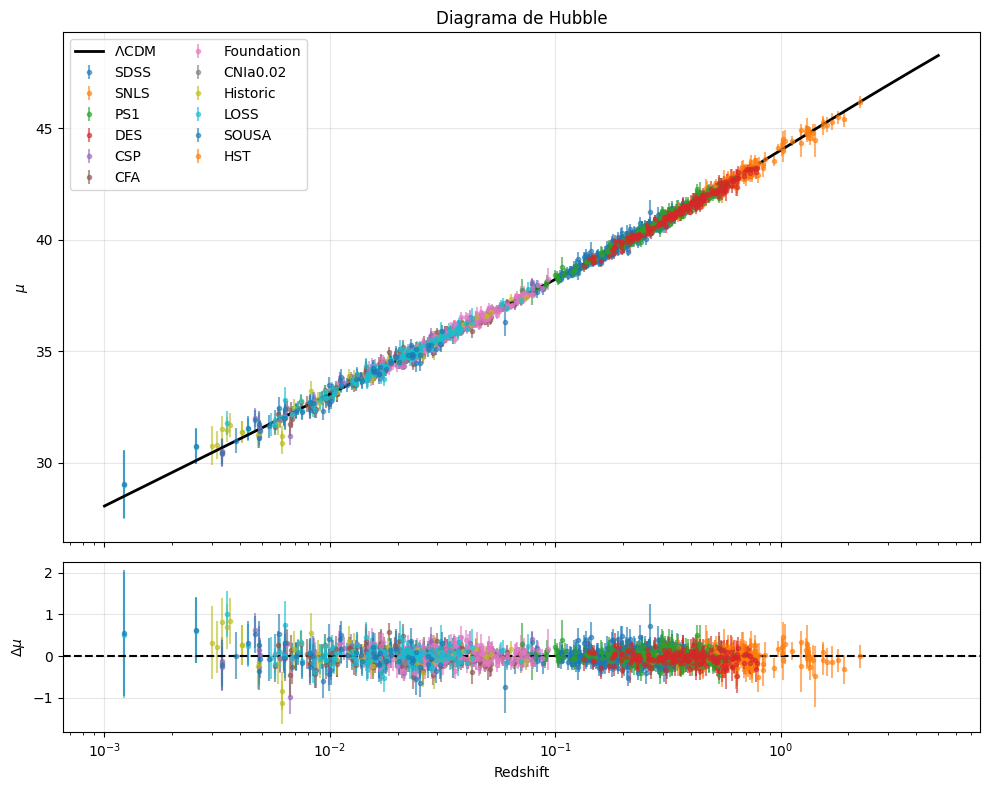

In [16]:
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(10,8),
    sharex=True,
    gridspec_kw={"height_ratios": [3,1]}
)

# =========================
# Painel superior
# =========================

for survey in survey_order:

    df_survey = df[df["SURVEY_NAME"] == survey]

    ax1.errorbar(
        df_survey["zHD"],
        df_survey["MU_SH0ES"],
        yerr=df_survey["MU_SH0ES_ERR_DIAG"],
        fmt=".",
        alpha=0.6,
        label=survey
    )

# Curva LCDM
ax1.plot(
    z_model,
    mu_model,
    color="black",
    lw=2,
    label=r"$\Lambda$CDM"
)

ax1.set_xscale("log")

ax1.set_ylabel(r"$\mu$")

ax1.set_title("Diagrama de Hubble")

ax1.legend(ncol=2)

ax1.grid(alpha=0.3)

# =========================
# Painel inferior
# =========================

for survey in survey_order:

    df_survey = df[df["SURVEY_NAME"] == survey]

    ax2.errorbar(
        df_survey["zHD"],
        df_survey["MU_RESIDUAL"],
        yerr=df_survey["MU_SH0ES_ERR_DIAG"],
        fmt=".",
        alpha=0.6
    )

ax2.axhline(
    0,
    color="black",
    linestyle="--"
)

ax2.set_xscale("log")

ax2.set_xlabel("Redshift")

ax2.set_ylabel(r"$\Delta \mu$")

ax2.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# Regressão Linear e a Lei de Hubble

Em baixos redshifts, a expansão do Universo pode ser descrita pela Lei de Hubble:

$$
v = H_0 d_L
$$

onde:

- $v$ é a velocidade de recessão da galáxia;
- $H_0$ é a constante de Hubble;
- $d_L$ é a distância luminosa.

Como para pequenos redshifts a velocidade pode ser aproximada por:

$$
v \approx cz
$$

temos:

$$
cz = H_0 d_L
$$

---

A distância luminosa pode ser obtida a partir do módulo de distância:

$$
\mu = 5\log_{10}(d_L)+25
$$

Isolando $d_L$:

$$
d_L = 10^{(\mu-25)/5}
$$

com $d_L$ em megaparsecs (Mpc).

---

Dessa forma, podemos transformar os dados observacionais de supernovas em um problema de regressão linear entre:

- $cz$ (velocidade)
- $d_L$ (distância)

Comparando com a equação da reta:

$$
y = ax+b
$$

podemos identificar:

$$
y \rightarrow cz
$$

$$
x \rightarrow d_L
$$

$$
a \rightarrow H_0
$$

Assim, o coeficiente angular da reta ajustada fornece uma estimativa observacional para a constante de Hubble.

In [17]:
df_hf = df[df["USED_IN_SH0ES_HF"] == 1].copy()

In [18]:
c = 299792.458  # km/s

# Distância luminosa em Mpc
df_hf["dL"] = 10**(
    (df_hf["MU_SH0ES"] - 25)/5
)

# cz em km/s
df_hf["cz"] = c * df_hf["zHD"]

In [26]:
from scipy.stats import linregress
import seaborn as sns

In [27]:
fit = linregress(
    df_hf["dL"],
    df_hf["cz"]
)

In [28]:
x_fit = np.linspace(
    df_hf["dL"].min(),
    df_hf["dL"].max(),
    100
)

y_fit = fit.slope * x_fit + fit.intercept

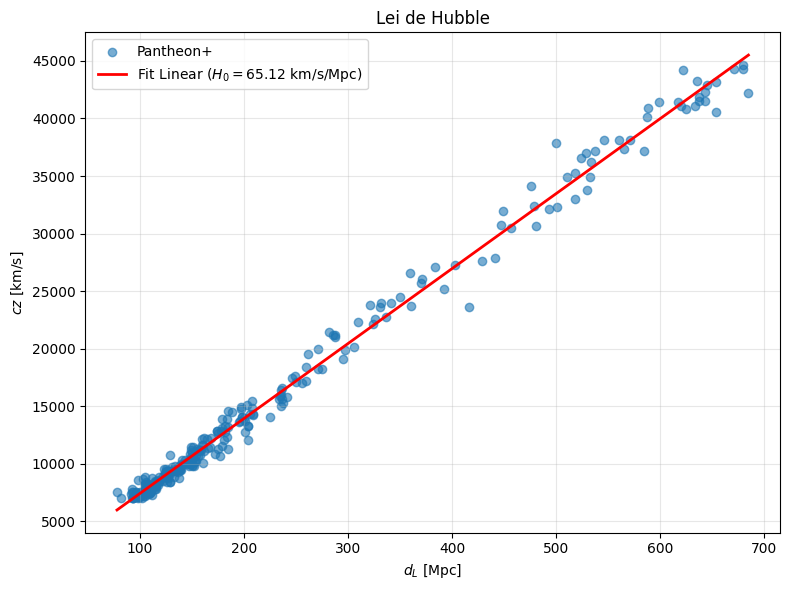

In [29]:
plt.figure(figsize=(8,6))

# Dados
plt.scatter(
    df_hf["dL"],
    df_hf["cz"],
    alpha=0.6,
    label="Pantheon+"
)

# Regressão linear
plt.plot(
    x_fit,
    y_fit,
    color="red",
    lw=2,
    label=rf"Fit Linear ($H_0={fit.slope:.2f}$ km/s/Mpc)"
)

plt.xlabel(r"$d_L$ [Mpc]")

plt.ylabel(r"$cz$ [km/s]")

plt.title("Lei de Hubble")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

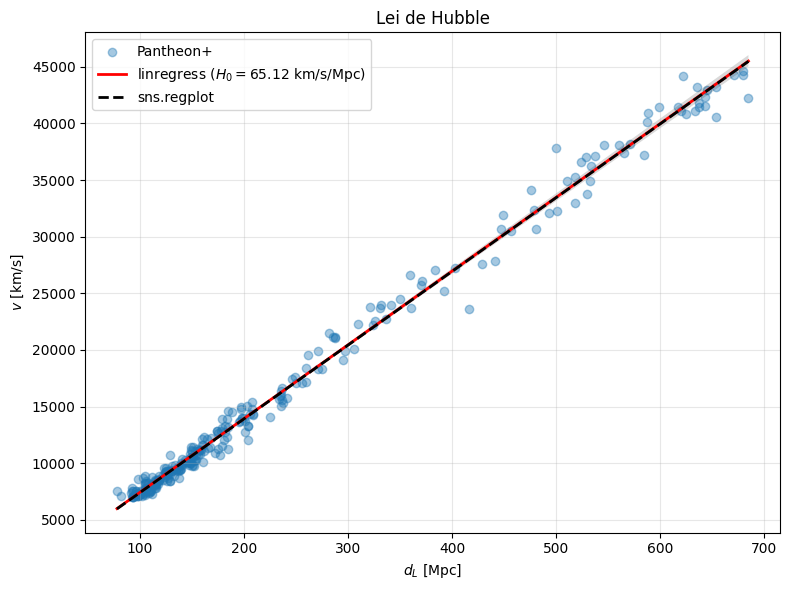

In [30]:
plt.figure(figsize=(8,6))

# =========================
# Dados
# =========================

plt.scatter(
    df_hf["dL"],
    df_hf["cz"],
    alpha=0.4,
    label="Pantheon+"
)

# =========================
# Regressão linear scipy
# =========================

plt.plot(
    x_fit,
    y_fit,
    color="red",
    lw=2,
    label=rf"linregress ($H_0={fit.slope:.2f}$ km/s/Mpc)"
)

# =========================
# Regressão seaborn
# =========================

sns.regplot(
    x="dL",
    y="cz",
    data=df_hf,
    scatter=False,
    robust=True,
    color="black",
    line_kws={"lw":2, "ls":"--"},
    label="sns.regplot"
)

plt.xlabel(r"$d_L$ [Mpc]")

plt.ylabel(r"$v$ [km/s]")

plt.title("Lei de Hubble")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
fit.slope

np.float64(65.11526731722283)

# Agrupando Dados em Bins de Redshift

Em análises cosmológicas, é comum agrupar os dados em intervalos de redshift, chamados de *bins*. Esse procedimento reduz a dispersão estatística dos dados observacionais e facilita a visualização de tendências globais no diagrama de Hubble.

Neste exemplo, os dados são agrupados em bins de redshift e, para cada intervalo, calculamos:

- o redshift médio;
- o resíduo médio;
- a incerteza média.

---

Os bins são construídos utilizando intervalos igualmente espaçados em escala logarítmica:

$$
z_{\mathrm{bin}}
\in
[z_i, z_{i+1}]
$$

Essa escolha é importante porque a distribuição de supernovas não é uniforme em redshift, cobrindo várias ordens de magnitude.

---

Após definir os bins, utilizamos o método `groupby()` do pandas para calcular as médias em cada intervalo de redshift.

O resultado final é um conjunto reduzido de pontos representativos da tendência média dos dados observacionais.

In [32]:
bins = np.logspace(
    np.log10(df["zHD"].min()),
    np.log10(df["zHD"].max()),
    13
)

In [33]:
df["z_bin"] = pd.cut(
    df["zHD"],
    bins=bins,
    include_lowest=True
)

In [34]:
df_binned = (
    df.groupby("z_bin")
    .agg({
        "zHD": "mean",
        "MU_RESIDUAL": "mean",
        "MU_SH0ES_ERR_DIAG": "mean"
    })
    .reset_index()
)

df_binned = df_binned.dropna()

/tmp/ipykernel_7019/1472266432.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("z_bin")


In [35]:
df_binned

,z_bin,zHD,MU_RESIDUAL,MU_SH0ES_ERR_DIAG
1,"(0.00228, 0.00428]",0.003360,0.328647,0.611434
2,"(0.00428, 0.00801]",0.006125,0.004183,0.418266
3,"(0.00801, 0.015]",0.011402,0.011894,0.319221
4,"(0.015, 0.0281]",0.021341,-0.019309,0.249260
5,"(0.0281, 0.0525]",0.036749,0.012460,0.214429
6,"(0.0525, 0.0983]",0.069706,-0.003086,0.213352
7,"(0.0983, 0.184]",0.148162,-0.005222,0.195582
8,"(0.184, 0.345]",0.261479,-0.003912,0.211019
9,"(0.345, 0.645]",0.470308,-0.034031,0.232982
10,"(0.645, 1.208]",0.759259,-0.046832,0.275460


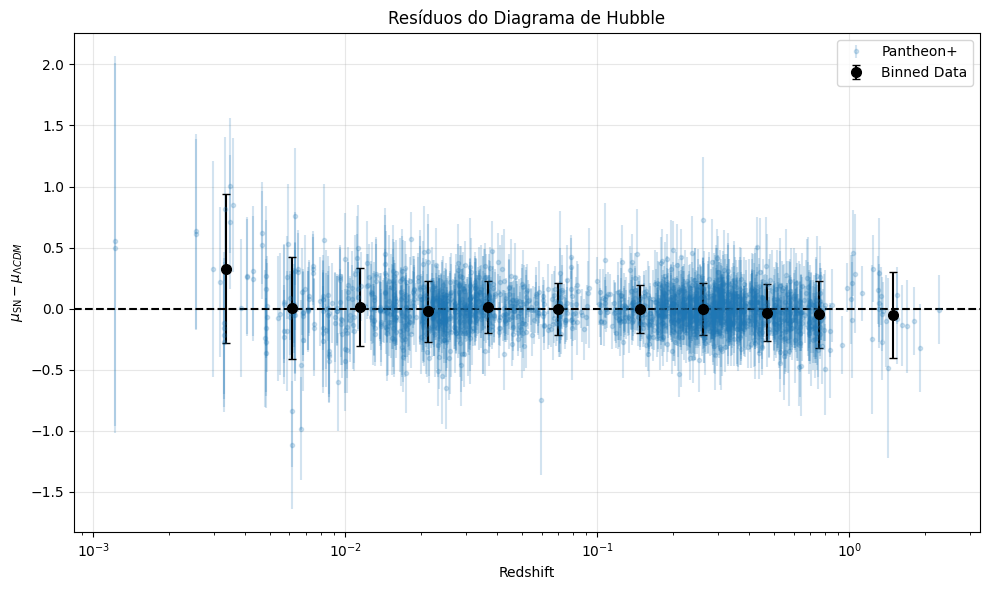

In [36]:
plt.figure(figsize=(10,6))

# =========================
# Dados individuais
# =========================

plt.errorbar(
    df["zHD"],
    df["MU_RESIDUAL"],
    yerr=df["MU_SH0ES_ERR_DIAG"],
    fmt=".",
    alpha=0.2,
    label="Pantheon+"
)

# =========================
# Dados binned
# =========================

plt.errorbar(
    df_binned["zHD"],
    df_binned["MU_RESIDUAL"],
    yerr=df_binned["MU_SH0ES_ERR_DIAG"],
    fmt="o",
    color="black",
    ms=7,
    capsize=3,
    label="Binned Data"
)

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.xscale("log")

plt.xlabel("Redshift")

plt.ylabel(
    r"$\mu_{\mathrm{SN}} - \mu_{\Lambda CDM}$"
)

plt.title("Resíduos do Diagrama de Hubble")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()